In [1]:
from pathlib import Path
import sys
from dataclasses import replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'src' / 'xp_config.py').is_file() and (p / 'experiment').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.xp_config import ExperimentConfig
from src.experiment import estimate_config
from src.fidelities import fidelities_over_time
from experiment.atom_evolution import run_atom_evolution

# Figure style from calibration_twophoton_waveguideQED, editable here.
colors = ['#003f5c', '#8e3e7a', '#ed9a00', '#2a4a79', '#c64f8b']
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'axes.linewidth': 0.7,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'axes.prop_cycle': plt.cycler(color=colors),
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'legend.frameon': False,
    'lines.linewidth': 1.0,
    'lines.markersize': 3,
    'figure.dpi': 300,
})
pd.set_option('display.float_format', '{:.9g}'.format)


# TLS evolution

Parameters follow the D, sigma_k and x_tls conventions. The coupling profile is `sqrt`, as in Uri's experiments.
Numerical functions live in `experiment/`; this notebook controls their inputs and displays results.
See the [mathematical and code documentation](../documentation/main.pdf).


## Parameters


In [ ]:
CTRL_M_EXPLICIT = True
M = 5                         # Must be odd; k=0 is included.
cutoffs = {'ir_cutoff': 0.0, 'uv_cutoff': 2.0}  # Used only when control is False.

param_atom = {'omega_0': 1.0, 
              'D': 0.2, 
              'L': 2*np.pi,
              'x_tls': 0.0, 
              'coupling': 'sqrt', 
              'initial_state': 'g'}

param_photon = {'k_0': 1.0, 
                'sigma_k': 0.4, 
                'x_0': -2.0,
                'state': 'number', 
                'n': 1, 
                'alpha': 1.0}

param_time_evol = {'T': 4.0, 'dt': 0.05, 'rtol': 1e-9, 'atol': 1e-11}

n_max = 2
truncation = 'full+totalcap'
RWA = False

config = ExperimentConfig(param_photon, param_atom, param_time_evol, cutoffs,
                          n_max=n_max, truncation=truncation, RWA=RWA,
                          CTRL_M_EXPLICIT=CTRL_M_EXPLICIT, M=M)


## Resource estimate

Informative only: the estimate does not stop execution. Memory covers retained complex vectors and excludes sparse matrices, Python objects and solver workspace.

In [3]:
schemes = ('full+totalcap', 'truncated')
config = replace(config, param_atom={**param_atom, 'initial_state': 'e'},
                 param_photon={**param_photon, 'n': 0})
estimate = pd.concat([estimate_config(replace(config, truncation=s)) for s in schemes],
                     keys=schemes, names=['scheme'])
display(estimate)

Value
scheme        Group  Parameter                          
full+totalcap Cavity omega_0                           1
                     D                               0.2
                     L                        6.28318531
                     x_tls                             0
                     coupling                       sqrt
                     initial_state                     e
              Modes  M                                 5
                     delta_k                           1
                     k_min                            -2
                     k_max                             2
                     IR_effective                      0
                     UV_effective                      2
              Time   T                                 4
                     dt                             0.05
                     rtol                          1e-09
                     atol                          1e-11
                     n_outputs                        81
              Memory basis                 full+totalcap
                     n_max                             2
                     dimension                        42
                     store_state                    True
                     ket_GiB               6.2584877e-07
                     history_GiB          5.06937504e-05
                     retained_vectors_GiB 0.000101387501
truncated     Cavity omega_0                           1
                     D                               0.2
                     L                        6.28318531
                     x_tls                             0
                     coupling                       sqrt
                     initial_state                     e
              Modes  M                                 5
                     delta_k                           1
                     k_min                            -2
                     k_max                             2
                     IR_effective                      0
                     UV_effective                      2
              Time   T                                 4
                     dt                             0.05
                     rtol                          1e-09
                     atol                          1e-11
                     n_outputs                        81
              Memory basis                     truncated
                     n_max                             2
                     dimension                        22
                     store_state                    True
                     ket_GiB              3.27825546e-07
                     history_GiB          2.65538692e-05
                     retained_vectors_GiB 5.31077385e-05

## Data generation

The associated Python module only generates numerical data.

In [4]:
runs = run_atom_evolution(config, schemes)

## Postprocessing

Prepare the arrays and DataFrames used by the plots below.

In [ ]:
times = runs['full+totalcap'].times
atom_data = {}
for scheme, exp in runs.items():
    # Normalize the field trace and evaluate S = -sum_j lambda_j log(lambda_j).
    rho = np.asarray(exp.compute_atom_density_matrix())
    rho /= np.trace(rho, axis1=1, axis2=2)[:, None, None]
    eigenvalues = np.clip(np.linalg.eigvalsh(rho), 0, 1)
    entropy = -np.sum(eigenvalues * np.log(np.clip(eigenvalues, np.finfo(float).tiny, 1)), axis=1)
    atom_data[scheme] = pd.DataFrame({
        'p_excited': exp.compute_excited_probability(),
        'entropy': entropy,
    }, index=pd.Index(exp.times, name='time'))
F = fidelities_over_time(runs['truncated'], runs['full+totalcap'])
fidelity_history = pd.DataFrame(F, index=pd.Index(times, name='time'))
fidelity_summary = pd.DataFrame({
    'initial': {name: values[0] for name, values in F.items()},
    'final': {name: values[-1] for name, values in F.items()},
    'time_mean': {name: np.mean(values) for name, values in F.items()},
}).rename_axis('fidelity')
display(fidelity_summary)

## Plots

All drawing code is visible and editable here.

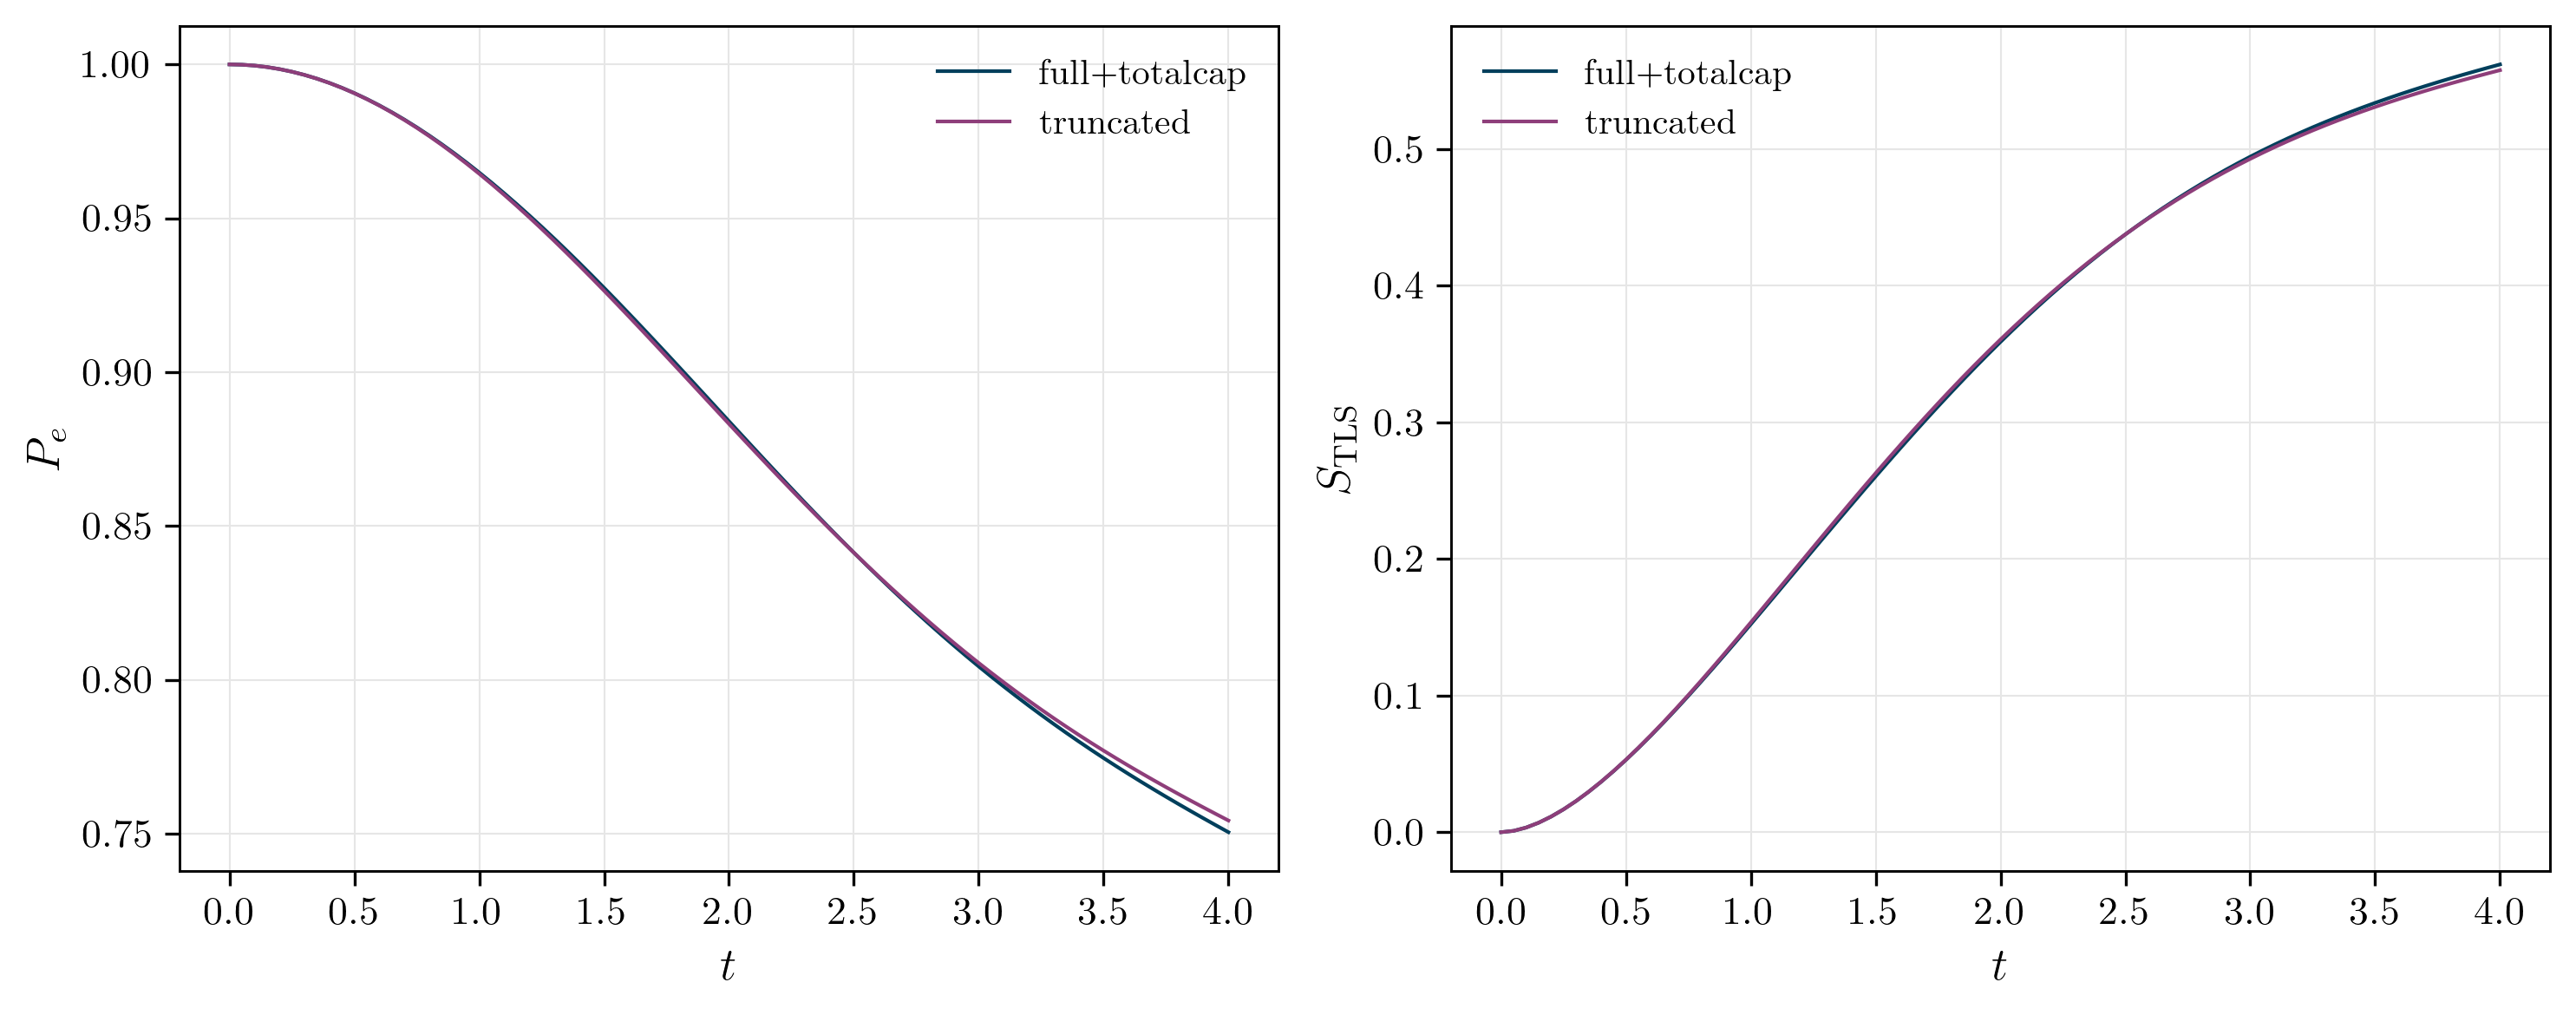

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for scheme, frame in atom_data.items():
    axes[0].plot(frame.index, frame['p_excited'], label=scheme)
    axes[1].plot(frame.index, frame['entropy'], label=scheme)
axes[0].set(xlabel=r'$t$', ylabel=r'$P_e$')
axes[1].set(xlabel=r'$t$', ylabel=r'$S_{\mathrm{TLS}}$')
for ax in axes:
    ax.legend()
for ax in axes.flat:
    ax.grid(color='0.9', linestyle='-', linewidth=0.5)
    ax.tick_params(length=4, width=0.8)
fig.tight_layout()
plt.show()

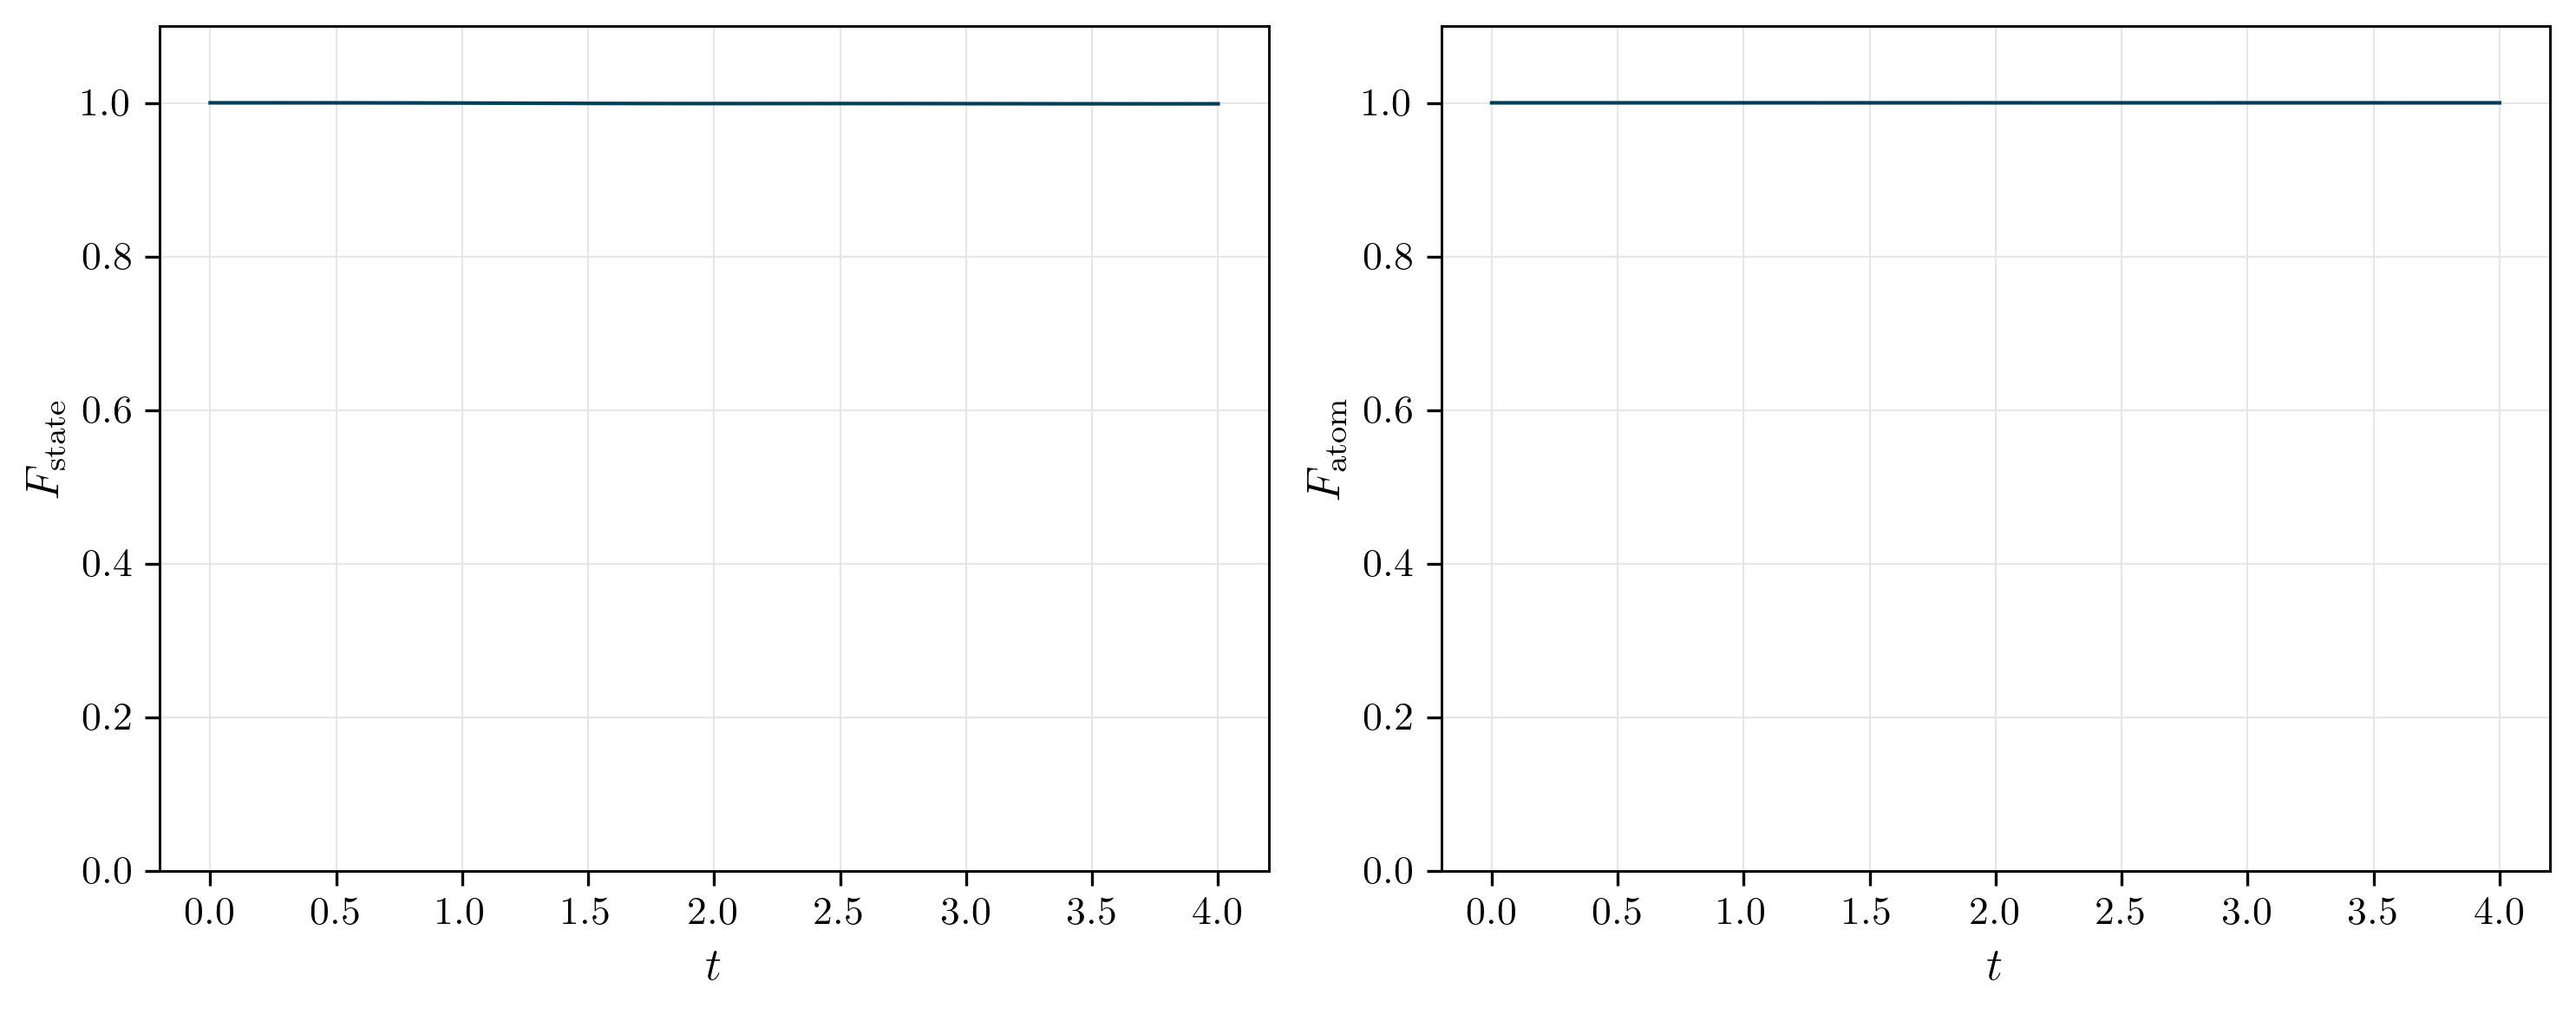

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name, label in zip(axes, ('F_state', 'F_atom'), (r'$F_{\mathrm{state}}$', r'$F_{\mathrm{atom}}$')):
    ax.plot(fidelity_history.index, fidelity_history[name])
    ax.set(xlabel=r'$t$', ylabel=label, ylim=(0, 1.1))
for ax in axes.flat:
    ax.grid(color='0.9', linestyle='-', linewidth=0.5)
    ax.tick_params(length=4, width=0.8)
fig.tight_layout()
plt.show()